# MIC 1175Ah 插入脉冲寿命仿真

客户工况配置保留在 notebook 中；通用的 step 构造、批量运行和电压曲线数据提取复用 BatteryProject/src。


## 1. 环境与导入

只在这一格完成路径定位、模块导入和 reload。


In [ ]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEARCH_ROOT = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents):
    if (candidate / "src" / "easy_imports.py").exists() and (candidate / "pyproject.toml").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError(f"Cannot locate BatteryProject root from {SEARCH_ROOT}")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.easy_imports import (
    DEFAULT_PULSE_LIFECYCLE_MODEL_OPTIONS,
    LIGHT_PULSE_LIFECYCLE_MODEL_OPTIONS,
    FULL_PULSE_LIFECYCLE_MODEL_OPTIONS,
    configure_notebook_environment,
    extract_cycle_voltage_curve,
    get_discharge_capacity,
    prepare_pulse_lifecycle_scenarios,
    run_pulse_lifecycle_scenarios,
)

PROJECT_ROOT, WORKSPACE_ROOT, PARAMS_ROOT = configure_notebook_environment(
    project_root=PROJECT_ROOT,
    include_workspace_root=True,
)

import paramsMIC as params_module

get_hithium_params = params_module.get_hithium_params

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "grid"])
except ImportError:
    plt.style.use("default")

plt.rcParams["font.family"] = "Calibri, Microsoft YaHei"


## 2. 工况配置

用户只需要改这一格：容量、电压边界、脉冲场景、运行模式和模型选项。


In [ ]:
NOMINAL_CAPACITY_AH = 1175.0
NOMINAL_VOLTAGE_V = 3.2
BASE_P_RATE = 0.25
TEMPERATURE_K = 298.15
INITIAL_SOC = None

CHARGE_CUTOFF_V = 3.65
DISCHARGE_CUTOFF_V = 2.50
REST_MINUTES = 30.0
PERIOD_MINUTES = 0.5

CAPACITY_CHECK_INTERVAL_CYCLES = 500
CAPACITY_CHECK_P_RATE = 0.25
CAPACITY_CHECK_AT_START = True

RUN_MODE = "study"
RUN_PROFILES = {
    "smoke": {
        "total_cycles": 4,
        "cycles_per_block": 1,
        "aging_t_factor": 1,
        "conditioning_t_factor": 1,
        "showprogress": True,
        "capacity_check_interval_cycles": CAPACITY_CHECK_INTERVAL_CYCLES,
        "capacity_check_p_rate": CAPACITY_CHECK_P_RATE,
        "capacity_check_at_start": CAPACITY_CHECK_AT_START,
        "adapt_pulse_windows_to_capacity": True,
    },
    "study": {
        "total_cycles": 10000,
        "cycles_per_block": 10,
        "aging_t_factor": 50,
        "conditioning_t_factor": 1,
        "showprogress": True,
        "capacity_check_interval_cycles": CAPACITY_CHECK_INTERVAL_CYCLES,
        "capacity_check_p_rate": CAPACITY_CHECK_P_RATE,
        "capacity_check_at_start": CAPACITY_CHECK_AT_START,
        "adapt_pulse_windows_to_capacity": True,
    },
}

PARALLEL_SCENARIOS = False
MAX_WORKERS = 2
RETURN_SOLUTIONS = True

MODEL_OPTIONS = dict(DEFAULT_PULSE_LIFECYCLE_MODEL_OPTIONS)
# DEFAULT 现在是 FULL；如需旧轻量模型，切到 LIGHT。
# MODEL_OPTIONS = dict(LIGHT_PULSE_LIFECYCLE_MODEL_OPTIONS)
VAR_PTS = {"x_n": 5, "x_s": 5, "x_p": 5, "r_n": 20, "r_p": 20}

SCENARIOS = [
    {
        "name": "baseline_0p25p",
        "display_name": "0.25P 基础充放循环",
        "pulse_p_rate": None,
        "pulse_seconds": None,
        "charge_interval_minutes": None,
        "discharge_interval_minutes": None,
        "charge_soc_window": (0.10, 0.90),
        "discharge_soc_window": (0.10, 0.90),
        "enabled": True,
    },
    {
        "name": "pulse_0p3p",
        "display_name": "0.3P 插入脉冲 2 min",
        "pulse_p_rate": 0.3,
        "pulse_seconds": 120.0,
        "charge_interval_minutes": 5.0,
        "discharge_interval_minutes": 5.0,
        "charge_soc_window": (0.10, 0.93),
        "discharge_soc_window": (0.10, 0.90),
        "enabled": True,
    },
    {
        "name": "pulse_0p375p",
        "display_name": "0.375P 插入脉冲 60 s",
        "pulse_p_rate": 0.375,
        "pulse_seconds": 60.0,
        "charge_interval_minutes": 30.0,
        "discharge_interval_minutes": 20.0,
        "charge_soc_window": (0.10, 0.76),
        "discharge_soc_window": (0.29, 1.00),
        "enabled": True,
    },
    {
        "name": "pulse_0p75p",
        "display_name": "0.75P 插入脉冲 13 s",
        "pulse_p_rate": 0.75,
        "pulse_seconds": 13.0,
        "charge_interval_minutes": 30.0,
        "discharge_interval_minutes": 20.0,
        "charge_soc_window": (0.10, 0.76),
        "discharge_soc_window": (0.30, 1.00),
        "enabled": True,
    },
]


## 3. 场景预览

把配置展开为可检查的等效循环/脉冲参数，先确认输入没有量纲或单位错误。


In [ ]:
prepared = prepare_pulse_lifecycle_scenarios(
    SCENARIOS,
    nominal_capacity_ah=NOMINAL_CAPACITY_AH,
    base_p_rate=BASE_P_RATE,
    nominal_voltage_v=NOMINAL_VOLTAGE_V,
    charge_cutoff_v=CHARGE_CUTOFF_V,
    discharge_cutoff_v=DISCHARGE_CUTOFF_V,
    rest_minutes=REST_MINUTES,
    period_minutes=PERIOD_MINUTES,
)
prepared["scenario_table"]


,enabled,scenario,base_p_rate,pulse_p_rate,pulse_seconds,charge_interval_minutes,discharge_interval_minutes,charge_soc_window,discharge_soc_window,step_count_per_cycle
0,True,0.25P 基础充放循环,0.25,NaN,NaN,NaN,NaN,"(0.1, 0.9)","(0.1, 0.9)",4
1,True,0.3P 插入脉冲 2 min,0.25,0.300,120.0,5.0,5.0,"(0.1, 0.9)","(0.1, 0.9)",118
2,True,0.375P 插入脉冲 60 s,0.25,0.375,60.0,30.0,20.0,"(0.1, 0.7)","(0.3, 1.0)",31
3,True,0.75P 插入脉冲 13 s,0.25,0.750,13.0,30.0,20.0,"(0.1, 0.7)","(0.3, 1.0)",33


## 4. 寿命仿真

调用统一的 run_pulse_lifecycle_scenarios，notebook 不再展开底层循环。


In [ ]:
pulse_bundle = run_pulse_lifecycle_scenarios(
    scenarios=SCENARIOS,
    runtime_config=RUN_PROFILES[RUN_MODE],
    model_options=MODEL_OPTIONS,
    var_pts=VAR_PTS,
    nominal_capacity_ah=NOMINAL_CAPACITY_AH,
    temperature_k=TEMPERATURE_K,
    get_hithium_params=get_hithium_params,
    get_discharge_capacity_func=get_discharge_capacity,
    base_p_rate=BASE_P_RATE,
    nominal_voltage_v=NOMINAL_VOLTAGE_V,
    charge_cutoff_v=CHARGE_CUTOFF_V,
    discharge_cutoff_v=DISCHARGE_CUTOFF_V,
    rest_minutes=REST_MINUTES,
    period_minutes=PERIOD_MINUTES,
    initial_soc=INITIAL_SOC,
    parallel=PARALLEL_SCENARIOS,
    max_workers=MAX_WORKERS,
    keep_only_last_cycle_solution=True,
    keep_only_last_capacity_check_solution=True,
    return_solutions=RETURN_SOLUTIONS,
)

results = pulse_bundle["results"]
capacity_check_df = pulse_bundle["capacity_check_df"]
summary_df = pulse_bundle["summary_df"].sort_values("scenario").reset_index(drop=True)
summary_df


,scenario,real_cycles_covered,final_capacity_ah,final_capacity_retention_pct,final_capacity_source,final_q_sei_ah,final_q_plating_ah
0,0.25P 基础充放循环,10000.0,1109.176792,91.442318,capacity_check,104.682590,0.0
1,0.375P 插入脉冲 60 s,10000.0,1109.866615,91.499188,capacity_check,103.995765,0.0
2,0.3P 插入脉冲 2 min,10000.0,1111.534574,91.636697,capacity_check,102.328062,0.0
3,0.75P 插入脉冲 13 s,10000.0,1109.826092,91.495847,capacity_check,104.036112,0.0


## 5. 容量保持率后处理与导出

集中处理手动校正、容量检查和 Excel 导出。


WindowsPath('D:/Users/hez/Desktop/hithium/BatteryProject/output/mic_pulse_lifecycle_results.xlsx')

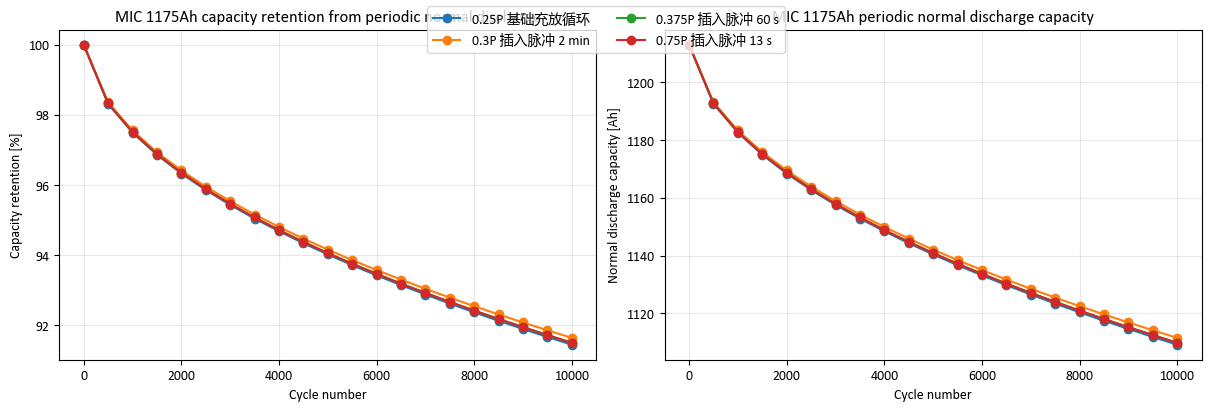

In [ ]:
POSTPROCESS_SCENARIO_ADJUSTMENTS = {
    # 示例：按 scenario_name 手动修正后处理曲线；空字典表示不修正。
    # "pulse_0p3p": {
    #     "capacity_scale": 1.01,       # Ah 曲线乘法修正
    #     "capacity_offset_ah": 0.0,    # Ah 曲线加法修正
    #     "retention_scale": 1.0,       # retention 分数乘法修正
    #     "retention_offset": -0.01,    # retention 分数加法修正，-0.01 = -1 pct point
    # },
}


def apply_capacity_postprocess_adjustment(capacity_df, scenario_name):
    adjusted = capacity_df.copy()
    adjustment = POSTPROCESS_SCENARIO_ADJUSTMENTS.get(scenario_name, {})

    raw_capacity = pd.to_numeric(
        adjusted["capacity_check_discharge_capacity_ah"],
        errors="coerce",
    )
    raw_retention = pd.to_numeric(adjusted["capacity_retention"], errors="coerce")

    adjusted["capacity_check_discharge_capacity_ah_raw"] = raw_capacity
    adjusted["capacity_retention_raw"] = raw_retention
    adjusted["capacity_scale"] = float(adjustment.get("capacity_scale", 1.0))
    adjusted["capacity_offset_ah"] = float(adjustment.get("capacity_offset_ah", 0.0))
    adjusted["retention_scale"] = float(adjustment.get("retention_scale", 1.0))
    adjusted["retention_offset"] = float(adjustment.get("retention_offset", 0.0))

    adjusted["capacity_check_discharge_capacity_ah_adjusted"] = (
        raw_capacity * adjusted["capacity_scale"] + adjusted["capacity_offset_ah"]
    )
    adjusted["capacity_retention_adjusted"] = (
        raw_retention * adjusted["retention_scale"] + adjusted["retention_offset"]
    )
    return adjusted


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), constrained_layout=False)
capacity_check_adjusted_frames = []

for bundle in results.values():
    scenario_name = bundle["scenario"]["name"]
    label = bundle["scenario"]["display_name"]
    capacity_df = bundle.get("capacity_check_df", pd.DataFrame())
    if capacity_df.empty:
        continue

    plot_df = apply_capacity_postprocess_adjustment(capacity_df, scenario_name)
    plot_df["scenario_name"] = scenario_name
    plot_df["scenario"] = label
    capacity_check_adjusted_frames.append(plot_df)

    axes[0].plot(
        plot_df["real_cycle"],
        plot_df["capacity_retention_adjusted"] * 100.0,
        marker="o",
        label=label,
    )
    axes[1].plot(
        plot_df["real_cycle"],
        plot_df["capacity_check_discharge_capacity_ah_adjusted"],
        marker="o",
        label=label,
    )

capacity_check_adjusted_df = (
    pd.concat(capacity_check_adjusted_frames, ignore_index=True)
    if capacity_check_adjusted_frames
    else pd.DataFrame()
)

axes[0].set_xlabel("Cycle number")
axes[0].set_ylabel("Capacity retention [%]")
axes[0].set_title("MIC 1175Ah capacity retention from periodic normal discharge", pad=10)
axes[0].ticklabel_format(axis="y", style="plain", useOffset=False)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Cycle number")
axes[1].set_ylabel("Normal discharge capacity [Ah]")
axes[1].set_title("MIC 1175Ah periodic normal discharge capacity", pad=10)
axes[1].ticklabel_format(axis="y", style="plain", useOffset=False)
axes[1].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(top=0.70, bottom=0.15, wspace=0.24)
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=2,
    frameon=False,
)

output_path = PROJECT_ROOT / "output" / "mic_pulse_lifecycle_results.xlsx"
output_path.parent.mkdir(parents=True, exist_ok=True)

with pd.ExcelWriter(output_path) as writer:
    summary_df.to_excel(writer, sheet_name="summary", index=False)
    capacity_check_df.to_excel(writer, sheet_name="capacity_check_raw", index=False)
    capacity_check_adjusted_df.to_excel(writer, sheet_name="capacity_check_adjusted", index=False)
    for name, bundle in results.items():
        bundle["main_df"].to_excel(writer, sheet_name=f"{name}_main"[:31], index=False)
        bundle.get("capacity_check_df", pd.DataFrame()).to_excel(
            writer,
            sheet_name=f"{name}_capacity"[:31],
            index=False,
        )
output_path


## 6. 电压曲线检查

抽取有脉冲的场景，检查不同阶段的电压曲线。


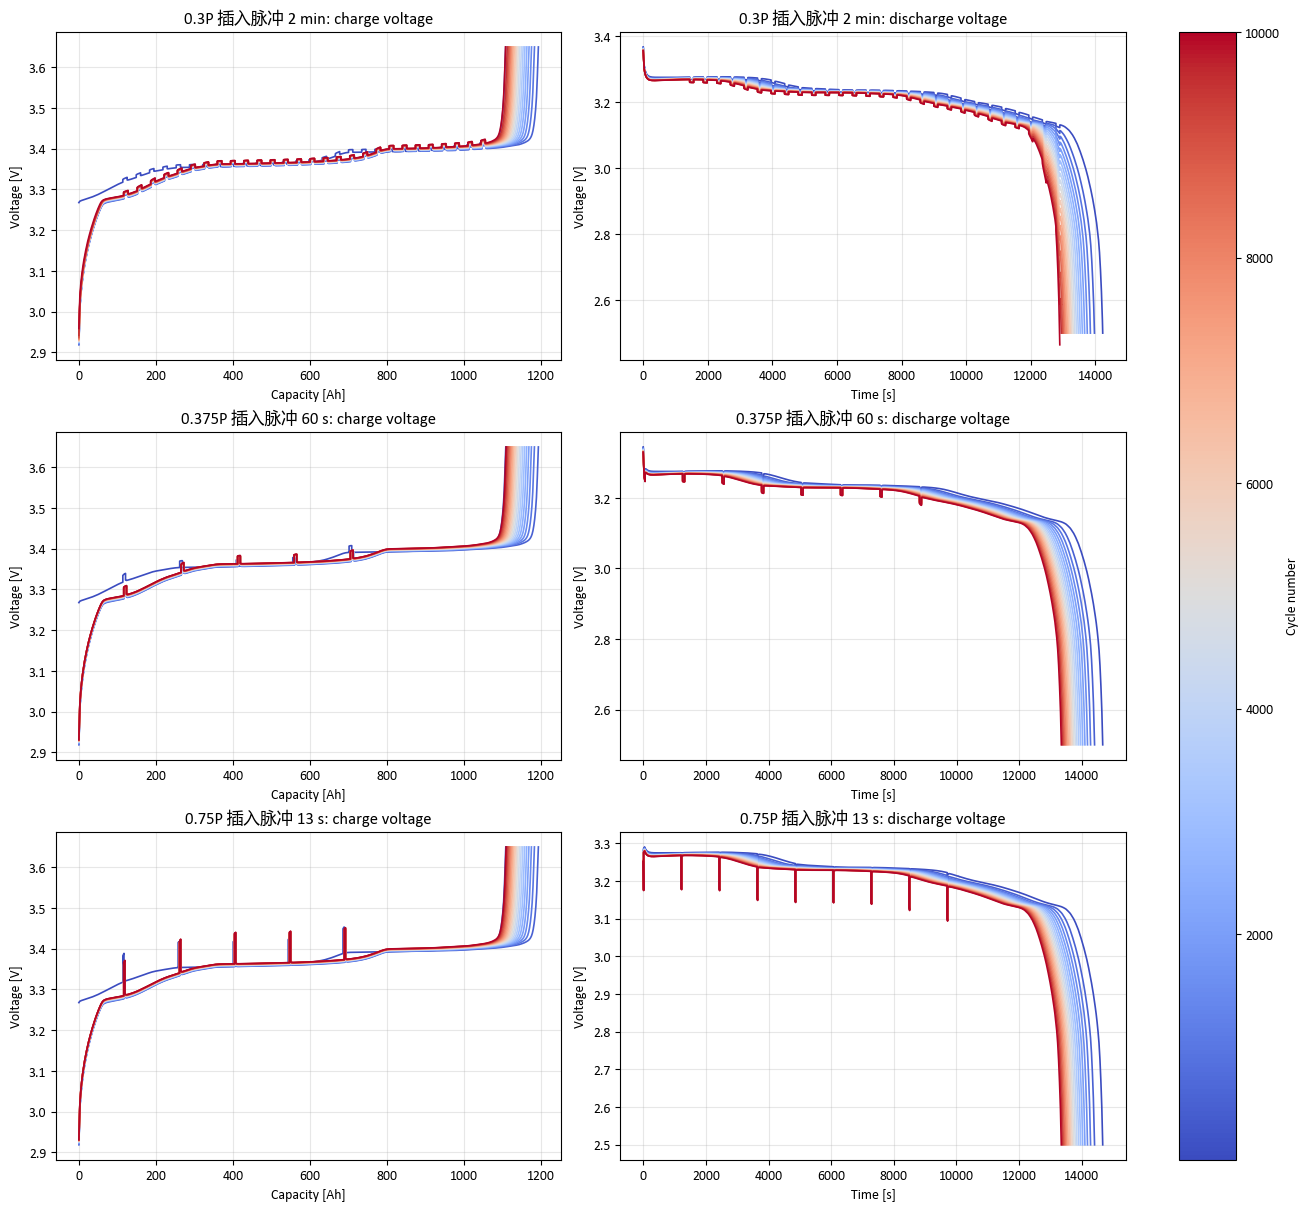

In [ ]:
voltage_scenarios = [scenario["name"] for scenario in SCENARIOS if scenario.get("pulse_p_rate") is not None]
fig, axes = plt.subplots(len(voltage_scenarios), 2, figsize=(13, 4 * len(voltage_scenarios)), constrained_layout=True)
axes = np.atleast_2d(axes)

max_cycle = max(
    (max(bundle.get("solution_real_cycles", [1])) for bundle in results.values() if bundle.get("solution_real_cycles")),
    default=1,
)
cmap = plt.get_cmap("coolwarm")
norm = plt.Normalize(vmin=1, vmax=max_cycle)

for row, scenario_name in enumerate(voltage_scenarios):
    bundle = results[scenario_name]
    solutions = bundle.get("solutions", [])
    real_cycles = bundle.get("solution_real_cycles", [])
    if not solutions:
        continue

    for sol, real_cycle in zip(solutions, real_cycles):
        cycle = sol.cycles[-1] if getattr(sol, "cycles", None) else sol
        color = cmap(norm(real_cycle))
        charge = extract_cycle_voltage_curve(cycle, direction="charge", x_axis="capacity")
        discharge = extract_cycle_voltage_curve(cycle, direction="discharge", x_axis="time")
        if charge["x"].size:
            axes[row, 0].plot(charge["x"], charge["voltage"], color=color, linewidth=1.2)
        if discharge["x"].size:
            axes[row, 1].plot(discharge["x"], discharge["voltage"], color=color, linewidth=1.2)

    label = bundle["scenario"]["display_name"]
    axes[row, 0].set_title(f"{label}: charge voltage")
    axes[row, 0].set_xlabel("Capacity [Ah]")
    axes[row, 0].set_ylabel("Voltage [V]")
    axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].set_title(f"{label}: discharge voltage")
    axes[row, 1].set_xlabel("Time [s]")
    axes[row, 1].set_ylabel("Voltage [V]")
    axes[row, 1].grid(True, alpha=0.3)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes.ravel().tolist(), label="Cycle number")
